# 07 — Custo, tempo e esforço operacional

Análise operacional dos modelos usados pela ferramenta.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
Quanto custa, quanto demora e quanto esforço operacional cada modelo exige na ferramenta?

Os chats comerciais ficam fora deste estudo porque os artefatos deles não trazem custo, latência e chamadas comparáveis.

In [2]:
tool = df_ferramenta.copy()
display(Markdown(f'### Base da ferramenta: {len(tool)} respostas'))
display(tool[['modelo_legivel','custo_estimado_usd','latencia_s','n_invocacoes','input_tokens','output_tokens']].describe())

### Base da ferramenta: 1350 respostas

,custo_estimado_usd,latencia_s,n_invocacoes,input_tokens,output_tokens
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000
mean,0.032308,11.641452,2.329630,12089.417778,369.435556
std,0.048501,9.321373,0.810565,11256.368741,248.019855
min,0.000940,1.760000,2.000000,4436.000000,56.000000
25%,0.004311,5.360000,2.000000,6669.750000,177.250000
50%,0.016270,9.525000,2.000000,9169.000000,298.500000
75%,0.040455,14.895000,2.000000,12281.500000,498.000000
max,0.643750,85.880000,7.000000,121340.000000,1809.000000


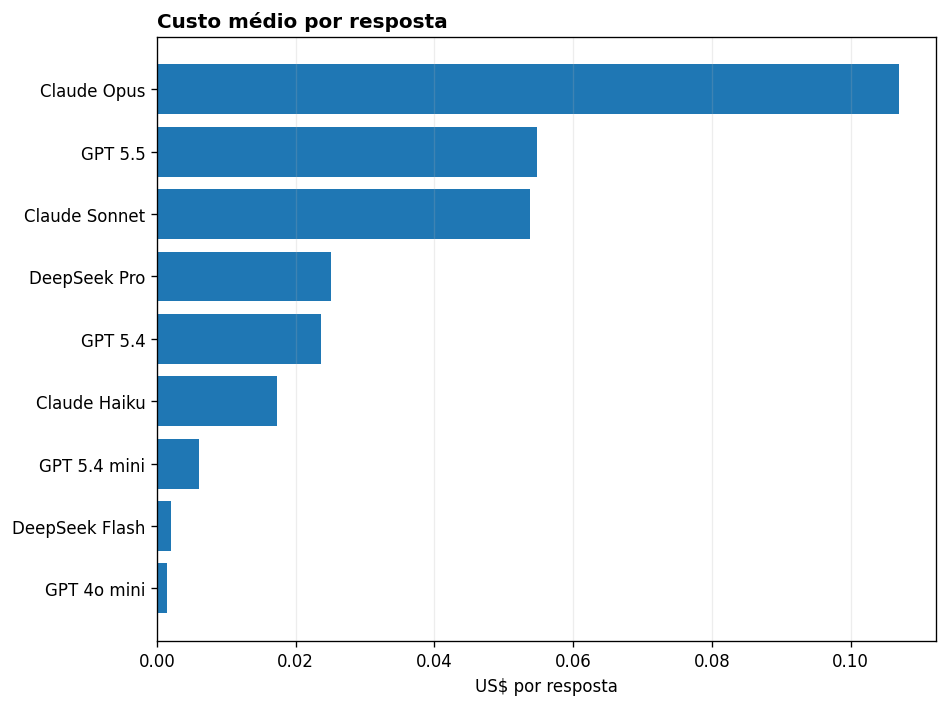

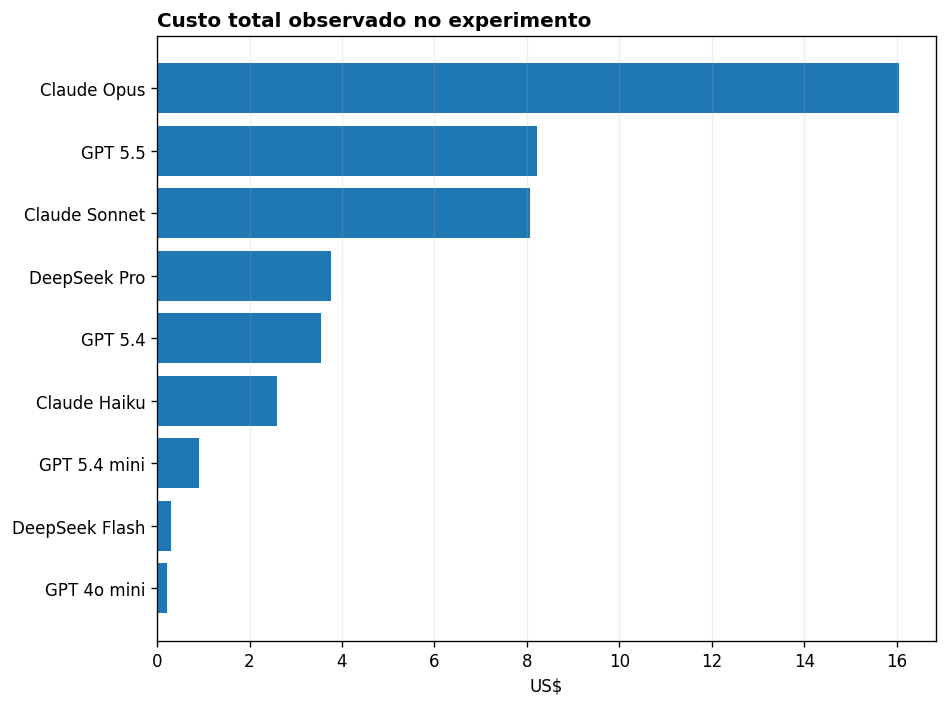

In [3]:
custo_medio = tool.groupby('modelo_legivel')['custo_estimado_usd'].mean().sort_values()
custo_total = tool.groupby('modelo_legivel')['custo_estimado_usd'].sum().sort_values()
barh_series(custo_medio, 'Custo médio por resposta', 'US$ por resposta', figsize=(8, 6))
barh_series(custo_total, 'Custo total observado no experimento', 'US$', figsize=(8, 6))

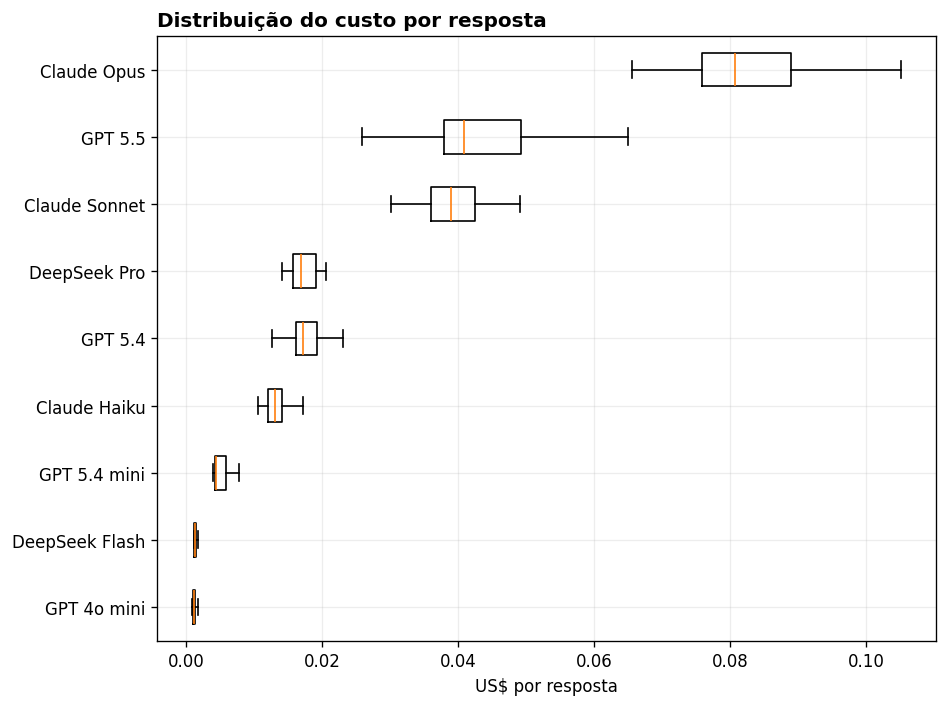

In [4]:
boxplot_por_grupo(tool, 'custo_estimado_usd', 'modelo_legivel', 'Distribuição do custo por resposta', 'US$ por resposta', figsize=(8, 6), ordem=custo_medio.index.tolist())

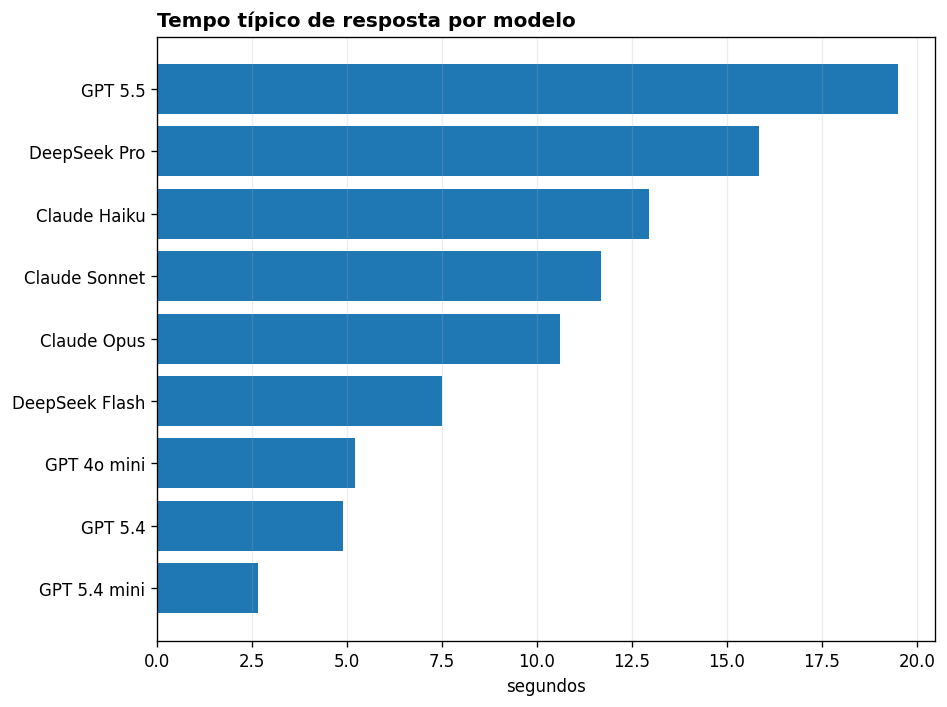

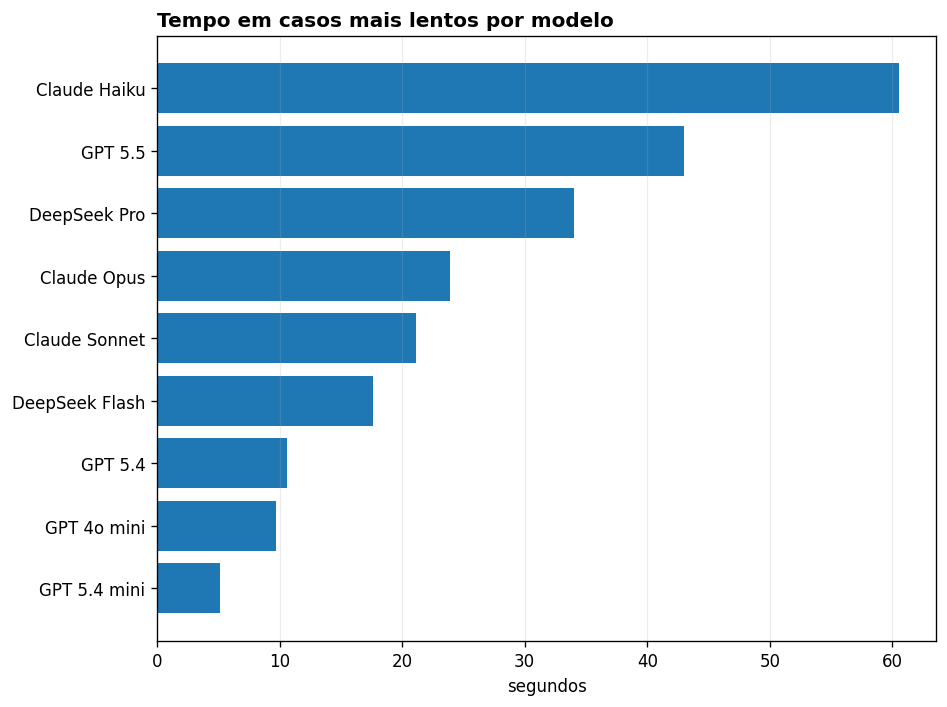

,modelo_legivel,tempo_medio,tempo_tipico,tempo_alto
0,GPT 5.4 mini,2.946,2.665,5.136
1,GPT 5.4,5.690,4.890,10.614
2,GPT 4o mini,5.632,5.200,9.734
3,DeepSeek Flash,8.562,7.505,17.645
4,Claude Opus,12.311,10.620,23.900
5,Claude Sonnet,12.917,11.675,21.090
6,Claude Haiku,17.502,12.955,60.528
7,DeepSeek Pro,17.885,15.850,34.058
8,GPT 5.5,21.328,19.505,43.010


In [5]:
lat = tool.groupby('modelo_legivel')['latencia_s'].agg(tempo_medio='mean', tempo_tipico='median', tempo_alto=lambda x: x.quantile(0.95)).sort_values('tempo_tipico')
barh_series(lat['tempo_tipico'], 'Tempo típico de resposta por modelo', 'segundos', figsize=(8, 6))
barh_series(lat['tempo_alto'], 'Tempo em casos mais lentos por modelo', 'segundos', figsize=(8, 6))
display(lat.reset_index().round(3))

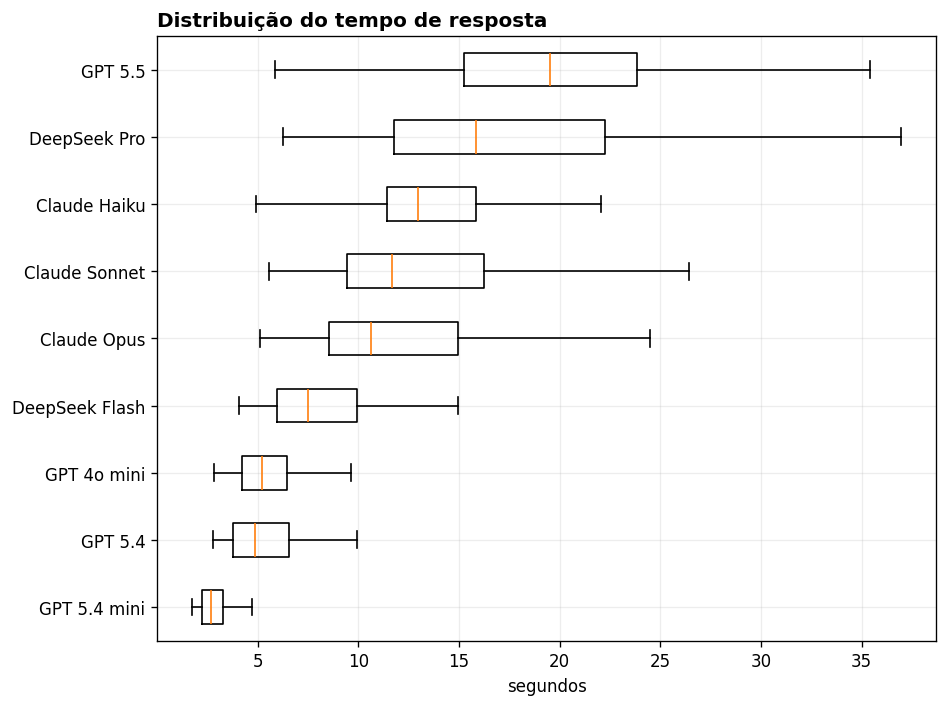

In [6]:
boxplot_por_grupo(tool, 'latencia_s', 'modelo_legivel', 'Distribuição do tempo de resposta', 'segundos', figsize=(8, 6), ordem=lat.index.tolist())

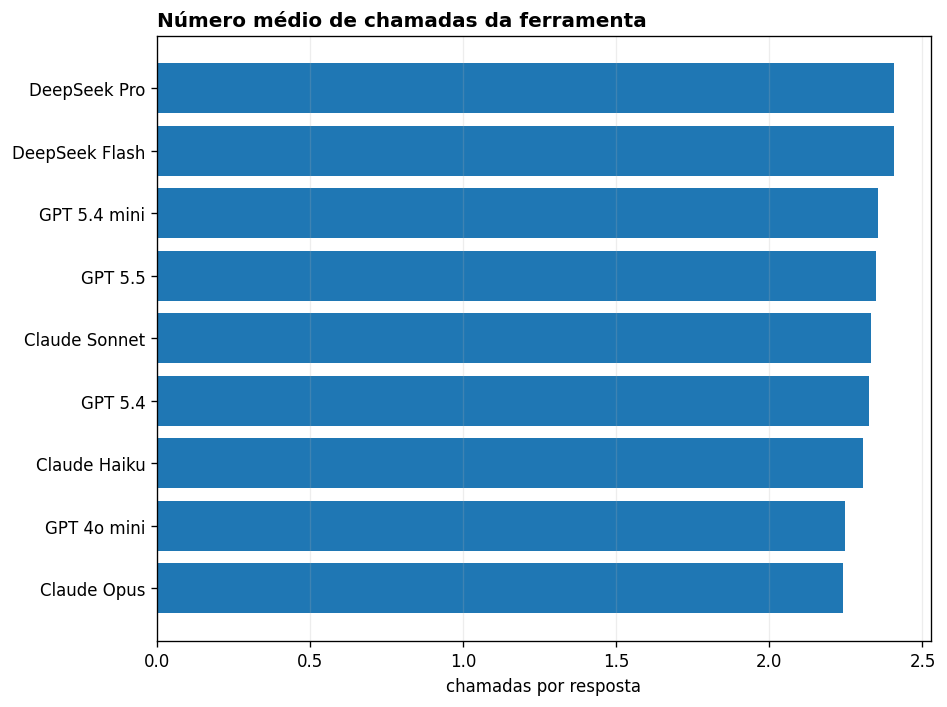

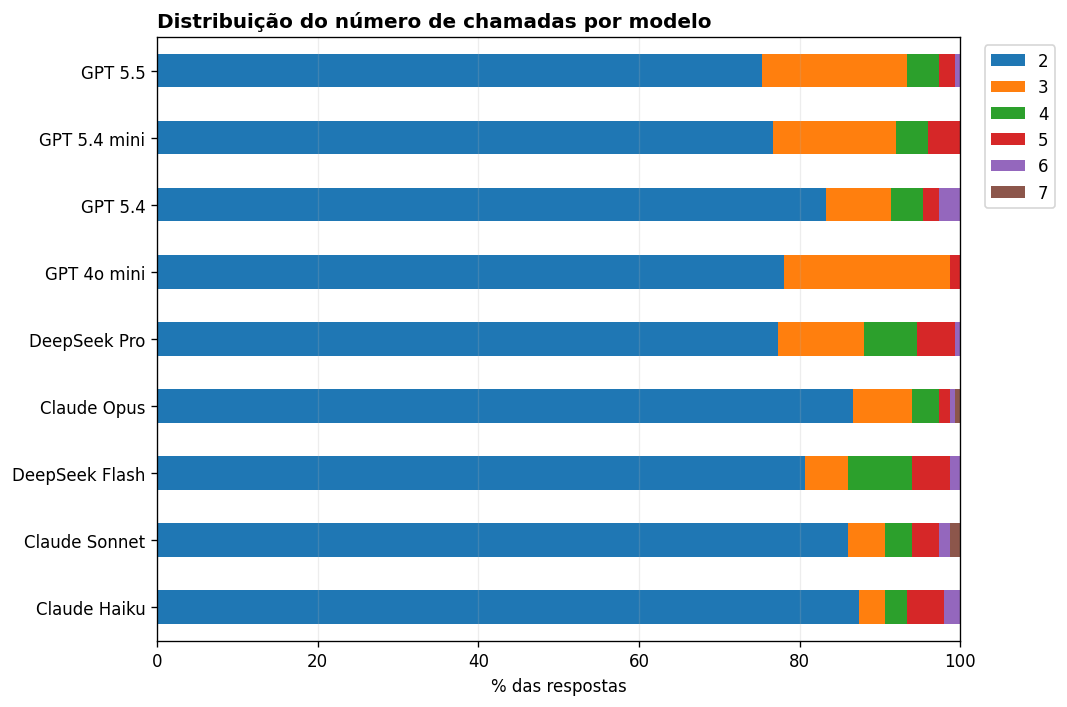

n_invocacoes,2,3,4,5,6,7
modelo_legivel,,,,,,
Claude Haiku,0.873333,0.033333,0.026667,0.046667,0.020000,0.000000
Claude Sonnet,0.860000,0.046667,0.033333,0.033333,0.013333,0.013333
DeepSeek Flash,0.806667,0.053333,0.080000,0.046667,0.013333,0.000000
Claude Opus,0.866667,0.073333,0.033333,0.013333,0.006667,0.006667
DeepSeek Pro,0.773333,0.106667,0.066667,0.046667,0.006667,0.000000
GPT 4o mini,0.780000,0.206667,0.000000,0.013333,0.000000,0.000000
GPT 5.4,0.833333,0.080000,0.040000,0.020000,0.026667,0.000000
GPT 5.4 mini,0.766667,0.153333,0.040000,0.040000,0.000000,0.000000
GPT 5.5,0.753333,0.180000,0.040000,0.020000,0.006667,0.000000


In [7]:
chamadas = tool.groupby('modelo_legivel')['n_invocacoes'].mean().sort_values()
barh_series(chamadas, 'Número médio de chamadas da ferramenta', 'chamadas por resposta', figsize=(8, 6))
stacked_percent(tool, 'modelo_legivel', 'n_invocacoes', 'Distribuição do número de chamadas por modelo', figsize=(9, 6))

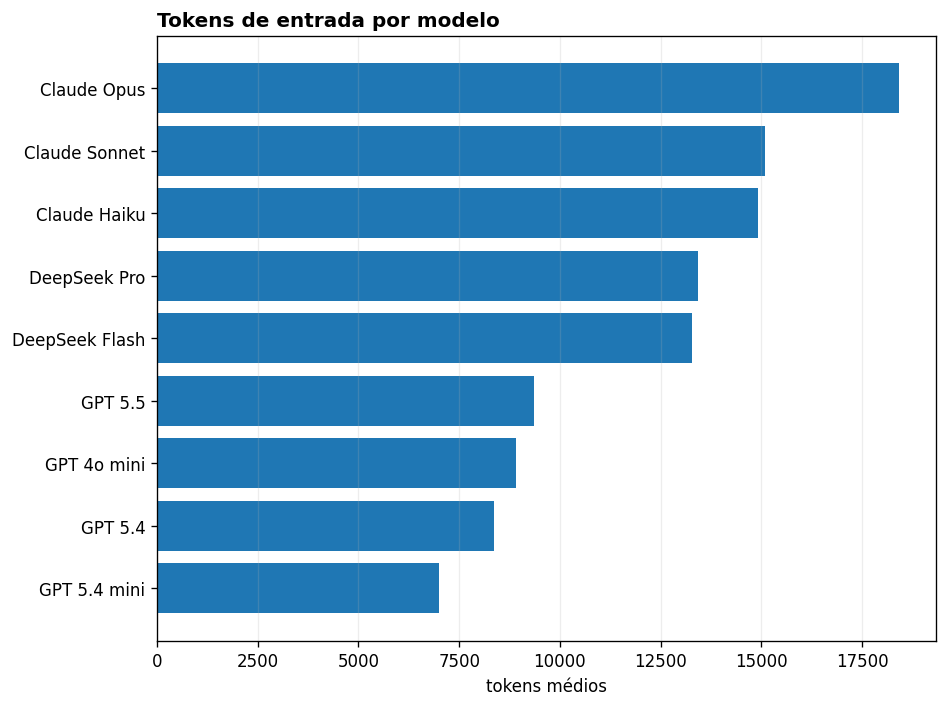

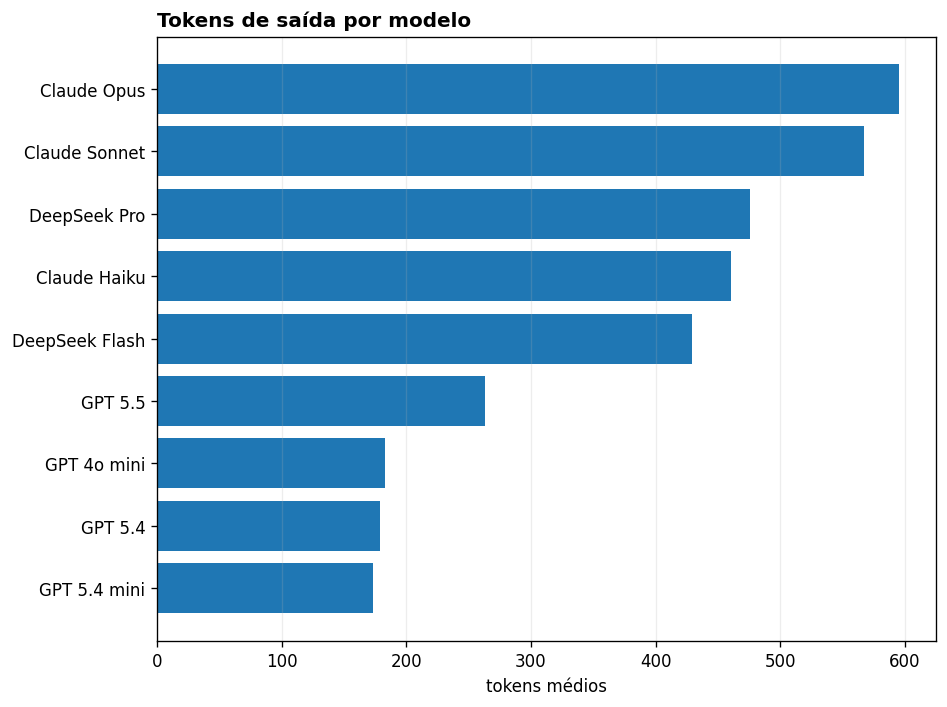

,modelo_legivel,entrada_media,saida_media,resposta_media
0,GPT 5.4 mini,6998.5,172.9,100.1
1,GPT 5.4,8367.4,178.6,107.4
2,GPT 4o mini,8921.5,182.7,140.7
3,GPT 5.5,9368.0,263.1,117.2
4,DeepSeek Flash,13289.4,429.0,264.6
5,Claude Haiku,14928.0,460.4,231.9
6,DeepSeek Pro,13422.1,475.7,296.5
7,Claude Sonnet,15093.6,567.3,321.4
8,Claude Opus,18416.4,595.2,271.7


In [8]:
tokens = tool.groupby('modelo_legivel').agg(
    entrada_media=('input_tokens','mean'),
    saida_media=('output_tokens','mean'),
    resposta_media=('resposta_tokens_tiktoken','mean')
).sort_values('saida_media')
barh_series(tokens['entrada_media'], 'Tokens de entrada por modelo', 'tokens médios', figsize=(8, 6))
barh_series(tokens['saida_media'], 'Tokens de saída por modelo', 'tokens médios', figsize=(8, 6))
display(tokens.round(1).reset_index())

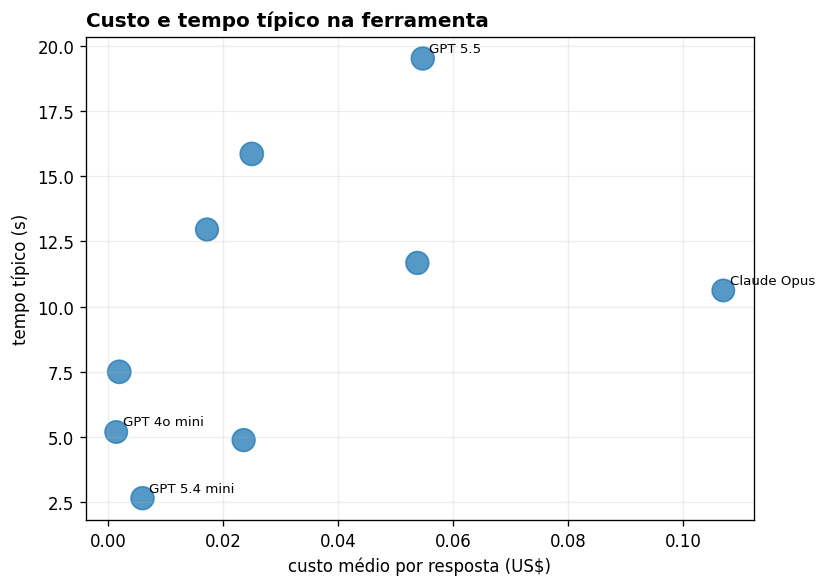

,modelo_legivel,custo,tempo,chamadas
0,GPT 4o mini,0.00145,5.200,2.24667
1,DeepSeek Flash,0.00198,7.505,2.40667
2,GPT 5.4 mini,0.00603,2.665,2.35333
3,Claude Haiku,0.01723,12.955,2.30667
4,GPT 5.4,0.02360,4.890,2.32667
5,DeepSeek Pro,0.02501,15.850,2.40667
6,Claude Sonnet,0.05379,11.675,2.33333
7,GPT 5.5,0.05473,19.505,2.34667
8,Claude Opus,0.10696,10.620,2.24000


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
m = tool.groupby('modelo_legivel').agg(custo=('custo_estimado_usd','mean'), tempo=('latencia_s','median'), chamadas=('n_invocacoes','mean')).sort_values('custo')
ax.scatter(m['custo'], m['tempo'], s=m['chamadas']*80, alpha=0.75)
ax.set_title('Custo e tempo típico na ferramenta', loc='left')
ax.set_xlabel('custo médio por resposta (US$)')
ax.set_ylabel('tempo típico (s)')
for nome, row in m.iterrows():
    if row['custo'] in [m['custo'].min(), m['custo'].max()] or row['tempo'] in [m['tempo'].min(), m['tempo'].max()]:
        ax.annotate(nome, (row['custo'], row['tempo']), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()
display(m.reset_index().round(5))